In [5]:
import pandas as pd 
import numpy as np

In [2]:
from synth_pat.paths import Paths

In [31]:
import os
zscores = pd.read_csv(
    os.path.join(Paths.DATA, "averaged_cortical_zscores.csv"), index_col=0)

In [34]:
import numpy as np
file = np.load(f"{Paths.RESULTS}/sigma_we_sweep.npz")
bold = file['bold']
raw= file['raw']
params = np.round(file['params'],4)

In [3]:
import matplotlib.pyplot as plt

In [27]:
sim_dir = f'{Paths.RESULTS}/sigma_we_features.npz'
sim_data = np.load(sim_dir)
sim_fc = sim_data['FC']
sim_fcd = sim_data['FCD']
sim_alff = sim_data['ALFF']
params = np.round(sim_data['params'],4)

sim_gbc = np.mean(sim_fc,axis=0)
sim_var_fcd = np.var(sim_fcd,axis=0)

sim_df = pd.DataFrame({'GBC': sim_gbc, 'VAR_FCD': sim_var_fcd, 'we': np.round(params[:,0],4), 'sigma': np.round(params[:,1],4)})

In [21]:
import seaborn as sns 

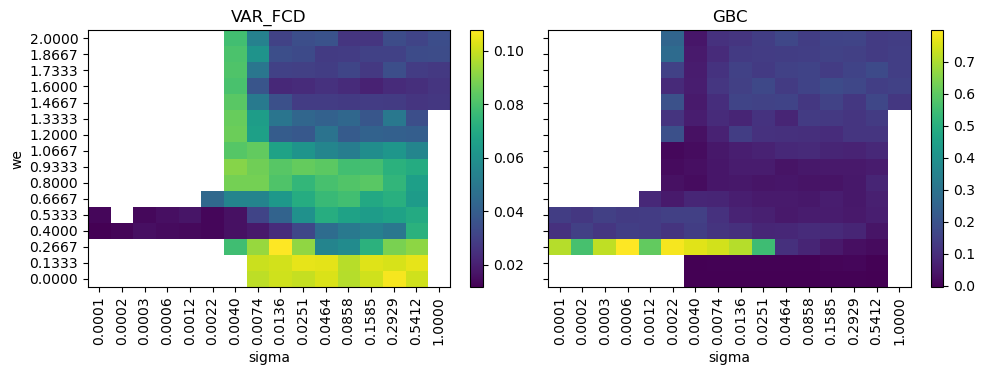

In [30]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["VAR_FCD", "GBC"]


fig, axes = plt.subplots(
    1, len(metrics),
    figsize=(5 * len(metrics), 4),
    sharex=True,
    sharey=True
)

for ax, metric in zip(axes, metrics):
    dfplot = sim_df.pivot(
        columns="sigma",
        index="we",
        values=metric
    )

    im = ax.imshow(
        dfplot.values,
        aspect="auto",
        origin="lower"
    )

    ax.set_title(metric)
    fig.colorbar(im, ax=ax, fraction=0.046)

    # ticks
    ax.set_xticks(np.arange(len(dfplot.columns)))
    ax.set_xticklabels([f"{x:.4f}" for x in dfplot.columns], rotation=90)

    ax.set_yticks(np.arange(len(dfplot.index)))
    ax.set_yticklabels([f"{y:.4f}" for y in dfplot.index])

    ax.set_xlabel("sigma")

axes[0].set_ylabel("we")
fig.suptitle(f"", fontsize=14)

plt.tight_layout()
plt.show()


[4.e-01 3.e-04]


/Users/giacomopreti/Desktop/VBT/GMV/scripts/plot_utils.py:7: RuntimeWarning: invalid value encountered in divide
  signal = (signal - smin)/(smax - smin)


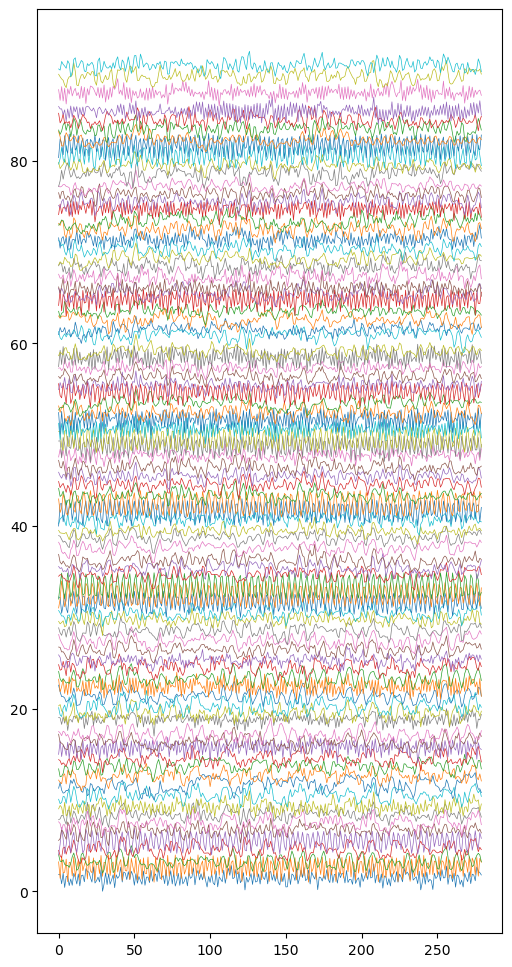

In [171]:
from scripts.plot_utils import plot_bold
idx = 50
print(params[idx])
plot_bold(bold[:,:,idx])

array([4.e-01, 1.e-04], dtype=float32)

In [43]:
params[0] == [0.    , 0.0001]

array([ True, False])

In [73]:
raw[:,:,1].shape

(28000, 90)

In [78]:
from synth_pat.scripts.plot_utils import plot_eeg
from synth_pat.scripts.simulation_utils import compute_eeg
from synth_pat.scripts.utils import prepare_fs_default

/Users/giacomopreti/Desktop/VBT/synthetic-patient/synth_pat/scripts/utils.py:73: SyntaxWarning: invalid escape sequence '\s'
  fs_default = pd.read_csv(f'{resources_dir}/fs_default.txt', sep='\s+', comment='#')
/Users/giacomopreti/Desktop/VBT/synthetic-patient/synth_pat/scripts/utils.py:83: SyntaxWarning: invalid escape sequence '\s'
  lut = pd.read_csv(f'{Paths.RESOURCES}/FreeSurferColorLUT.txt', sep='\s+', comment='#', names=["No", "Region", "R", "G", "B", "A"])


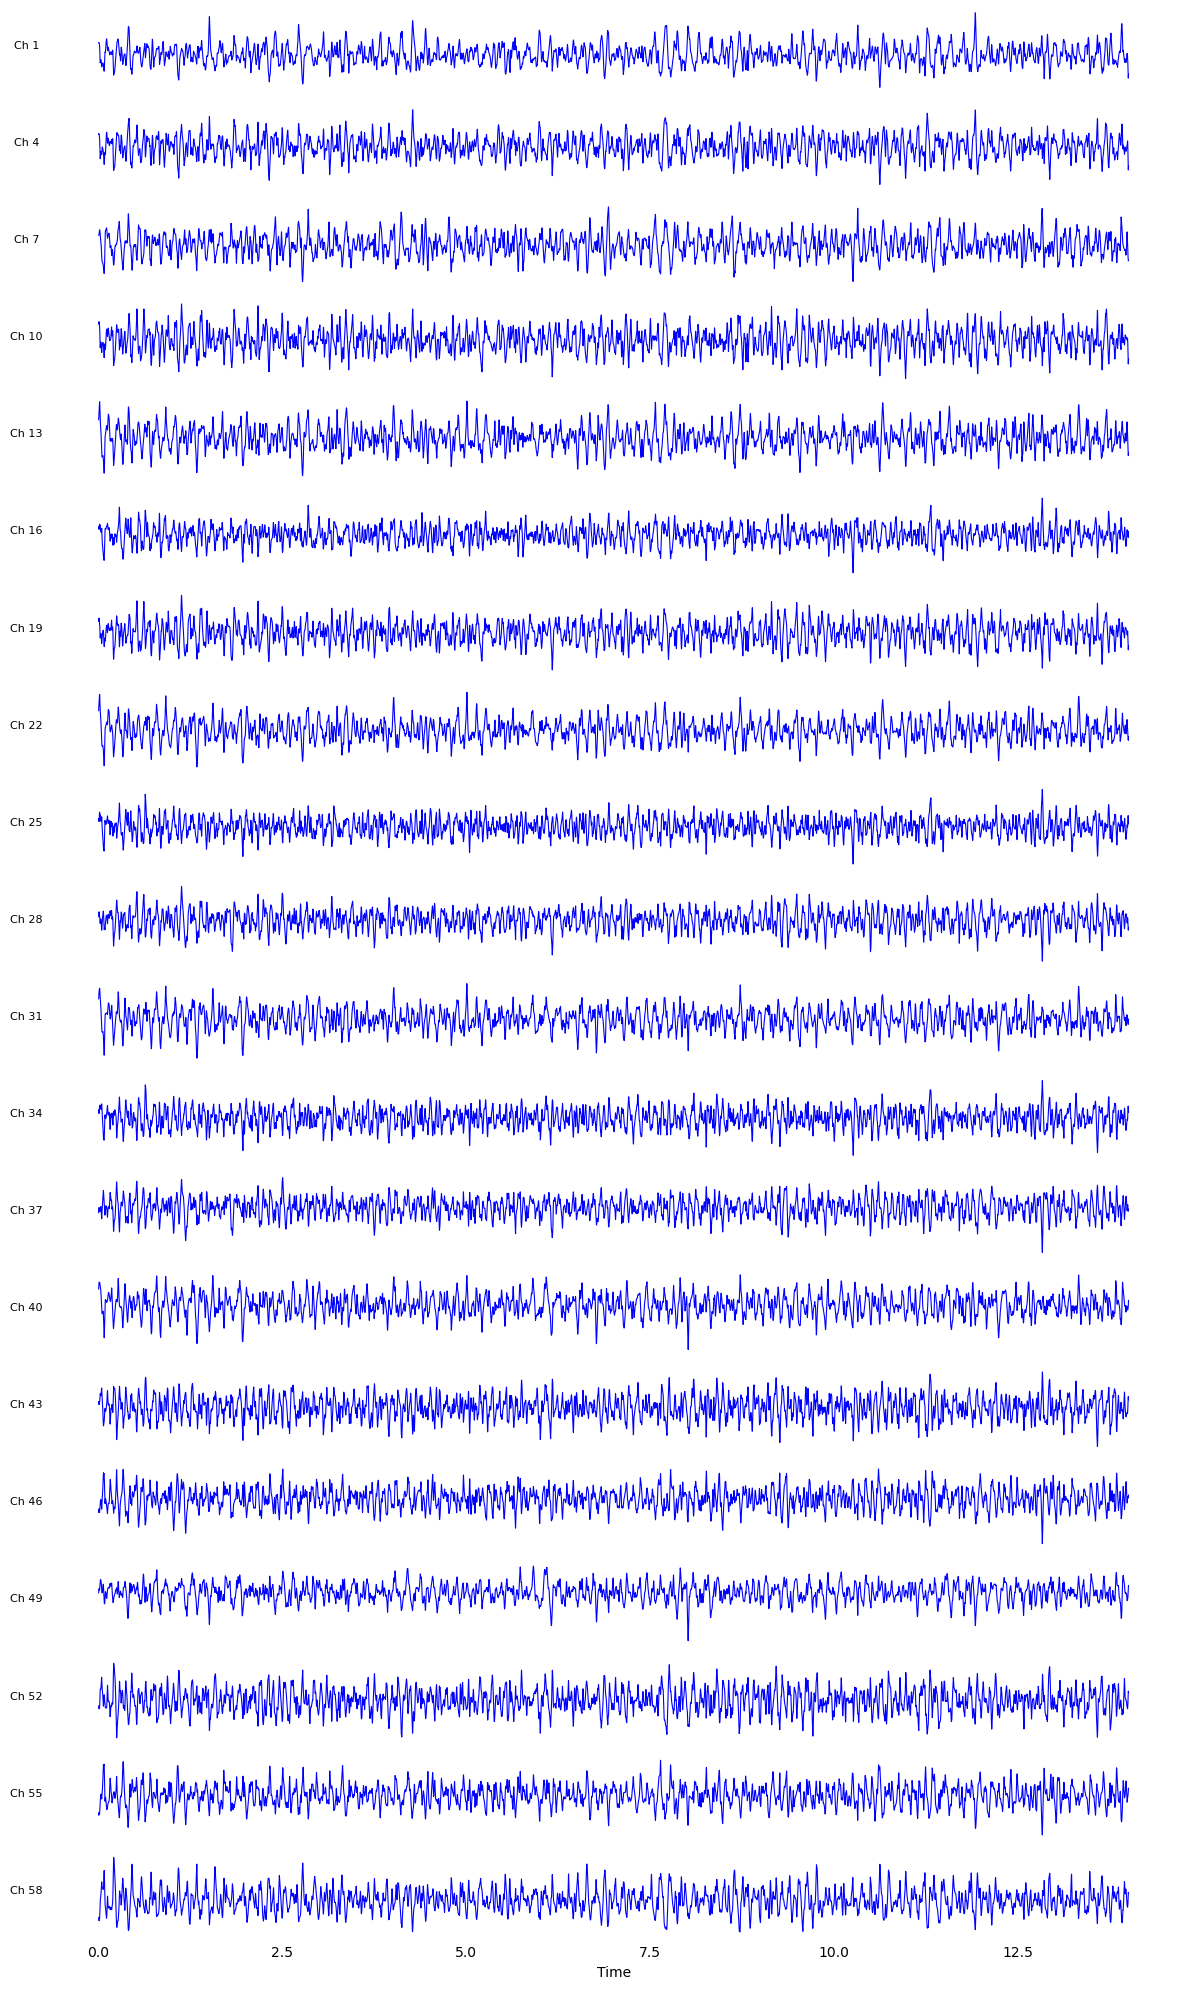

In [170]:
gain = np.load(f'{Paths.RESOURCES}/dk_L64_regions2channels_avg.npy')
regions_names = prepare_fs_default()['Label'].to_list()
channels = list(np.load(f"{Paths.RESOURCES}/dk_channel_names_list_64.npy"))
eeg = compute_eeg(raw[:,:,50], gain, regions_names)
plot_eeg(eeg, np.arange(0,60,3))

In [88]:
channels[0]

np.str_('Fp1')

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


def plot_psd(
    signal,
    fs,
    nperseg=1024,
    fmin=0,
    fmax=100,
    log_scale=True,
    title="EEG Power Spectral Density"
):
    """
    Plot PSD of an EEG signal using Welch's method.

    Parameters
    ----------
    signal : np.ndarray
        1D EEG time series
    fs : float
        Sampling frequency (Hz)
    nperseg : int
        Segment length for Welch
    fmin : float
        Minimum frequency to display
    fmax : float
        Maximum frequency to display
    log_scale : bool
        If True, plot power in dB
    """

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=nperseg,
        detrend="constant",
        scaling="density"
    )

    # Limit frequency range
    mask = (freqs >= fmin) & (freqs <= fmax)
    freqs = freqs[mask]
    psd = psd[mask]

    if log_scale:
        psd = 10 * np.log10(psd)

    plt.figure(figsize=(8, 4))
    plt.plot(freqs, psd)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (dB/Hz)" if log_scale else "Power")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


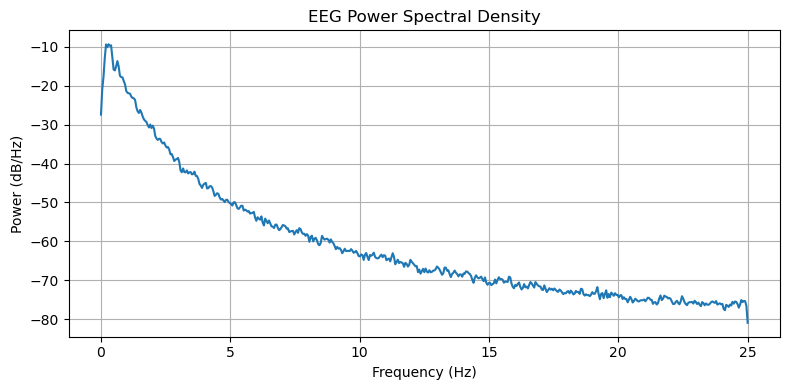

[4.e-01 3.e-04]


In [177]:
idx = 50
eeg = compute_eeg(raw[:,:,idx], gain, regions_names)
eeg = (eeg-eeg.min(axis=0))/(eeg.max(axis=0)-eeg.min(axis=0))
plot_psd(eeg[15,:], 50, fmin=0, fmax=80)
print(params[idx])

In [174]:
eeg[15,:].shape

(28000,)